#Monte Carlo Simulations

This project phase involves processing the data through monte carlo simulations, which will involve testing 1000 different ESG weightings to deduce if ESG variables have an effect on the distribution of the best performing portfolios.

In [8]:
!pip install yahoofinance
!git clone https://github.com/ArmandSDarmosusilo/Quantitative-ESG-Research-Project
!git -C Quantitative-ESG-Research-Project pull
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    median_absolute_error,
    explained_variance_score,
    max_error
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, PredefinedSplit

fatal: destination path 'Quantitative-ESG-Research-Project' already exists and is not an empty directory.
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4 (delta 2), reused 4 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 8.78 KiB | 4.39 MiB/s, done.
From https://github.com/ArmandSDarmosusilo/Quantitative-ESG-Research-Project
   6fc1210..8992498  main       -> origin/main
Updating 6fc1210..8992498
Fast-forward
 Data/stock_data.csv | 155 ++++++++++++++++++++++++++++++++++++++++++++++++++++
 1 file changed, 155 insertions(+)
 create mode 100644 Data/stock_data.csv


In [9]:
Sample_weight = {"E": 0.6, "S": 0.2, "G": 0.2}

E_weight = Sample_weight.get("E")
S_weight = Sample_weight.get("S")
G_weight = Sample_weight.get("G")

df_sim = pd.read_csv("Quantitative-ESG-Research-Project/Data/esg_stock.csv")

print("Original:")
display(df_sim)

df_sim["ENVIRON_DISCLOSURE_SCORE"] = df_sim['ENVIRON_DISCLOSURE_SCORE']*E_weight
df_sim["SOCIAL_DISCLOSURE_SCORE"] = df_sim['SOCIAL_DISCLOSURE_SCORE']*S_weight
df_sim["GOVNCE_DISCLOSURE_SCORE"] = df_sim['GOVNCE_DISCLOSURE_SCORE']*G_weight

df_sim["ESG_COMPOSITE_SCORE"] = df_sim["ENVIRON_DISCLOSURE_SCORE"]+df_sim["SOCIAL_DISCLOSURE_SCORE"]+df_sim["GOVNCE_DISCLOSURE_SCORE"]

Total_ESG = sum(df_sim["ESG_COMPOSITE_SCORE"])

print("\nSimulated:")
display(df_sim)

Original:


,Unnamed: 0,Ticker,Year,ESG_DISCLOSURE_SCORE,ENVIRON_DISCLOSURE_SCORE,SOCIAL_DISCLOSURE_SCORE,GOVNCE_DISCLOSURE_SCORE,Returns,Volatility,Sharpe_Ratio,Future_Sharpe,Future_Returns
0,0,bbca,2016,44.6032,8.0338,42.0496,83.5942,0.180646,0.158072,0.731606,1.958864,0.428937
1,1,bbca,2017,46.2428,8.0338,46.9770,83.5942,0.428937,0.185790,1.958864,0.617566,0.200174
2,2,bbca,2018,47.2991,11.2051,46.9770,83.5942,0.200174,0.218881,0.617566,1.562406,0.301435
3,3,bbca,2019,55.7288,25.5814,51.6324,89.8555,0.301435,0.151327,1.562406,-0.083070,0.033343
4,4,bbca,2020,55.7288,25.5814,51.6324,89.8555,0.033343,0.381091,-0.083070,0.139081,0.097071
...,...,...,...,...,...,...,...,...,...,...,...,...
118,118,jsmr,2020,50.5382,33.7964,34.0992,83.5942,-0.102008,0.552757,-0.302136,-0.704697,-0.159827
119,119,jsmr,2021,56.2821,51.0420,34.0992,83.5942,-0.159827,0.319041,-0.704697,-1.058686,-0.233933
120,120,jsmr,2022,60.2052,49.0788,47.8537,83.5942,-0.233933,0.282362,-1.058686,1.862996,0.670353
121,121,jsmr,2023,61.4123,49.0788,51.4813,83.5942,0.670353,0.324935,1.862996,-0.576506,-0.104099



Simulated:


,Unnamed: 0,Ticker,Year,ESG_DISCLOSURE_SCORE,ENVIRON_DISCLOSURE_SCORE,SOCIAL_DISCLOSURE_SCORE,GOVNCE_DISCLOSURE_SCORE,Returns,Volatility,Sharpe_Ratio,Future_Sharpe,Future_Returns,ESG_COMPOSITE_SCORE
0,0,bbca,2016,44.6032,4.82028,8.40992,16.71884,0.180646,0.158072,0.731606,1.958864,0.428937,29.94904
1,1,bbca,2017,46.2428,4.82028,9.39540,16.71884,0.428937,0.185790,1.958864,0.617566,0.200174,30.93452
2,2,bbca,2018,47.2991,6.72306,9.39540,16.71884,0.200174,0.218881,0.617566,1.562406,0.301435,32.83730
3,3,bbca,2019,55.7288,15.34884,10.32648,17.97110,0.301435,0.151327,1.562406,-0.083070,0.033343,43.64642
4,4,bbca,2020,55.7288,15.34884,10.32648,17.97110,0.033343,0.381091,-0.083070,0.139081,0.097071,43.64642
...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,118,jsmr,2020,50.5382,20.27784,6.81984,16.71884,-0.102008,0.552757,-0.302136,-0.704697,-0.159827,43.81652
119,119,jsmr,2021,56.2821,30.62520,6.81984,16.71884,-0.159827,0.319041,-0.704697,-1.058686,-0.233933,54.16388
120,120,jsmr,2022,60.2052,29.44728,9.57074,16.71884,-0.233933,0.282362,-1.058686,1.862996,0.670353,55.73686
121,121,jsmr,2023,61.4123,29.44728,10.29626,16.71884,0.670353,0.324935,1.862996,-0.576506,-0.104099,56.46238


In [10]:
weights = {
    "bbca": np.nan,
    "bbni": np.nan,
    "bbri": np.nan,
    "bmri": np.nan,
    "indf": np.nan,
    "jsmr": np.nan,
    "klbf": np.nan,
    "smgr": np.nan,
    "unvr": np.nan,
    "asii": np.nan,
    "tlkm": np.nan,
    "icbp": np.nan,
    "untr": np.nan,
    "antm": np.nan,
    "pgas": np.nan
}

for i in weights:
    ticker_data = df_sim[df_sim["Ticker"] == i]
    weights[i] = sum(ticker_data["ESG_COMPOSITE_SCORE"])/Total_ESG

print(weights)
print(sum(weights.values()))

{'bbca': 0.06719099428639891, 'bbni': 0.0681260417214853, 'bbri': 0.06665655631195831, 'bmri': 0.049169862694774163, 'indf': 0.05625247997721961, 'jsmr': 0.07781379279469049, 'klbf': 0.07221122056706675, 'smgr': 0.07464243796925592, 'unvr': 0.096666281921209, 'asii': 0.08475608276769904, 'tlkm': 0.061352336252224915, 'icbp': 0.05705500942912414, 'untr': 0.0, 'antm': 0.09340519344898564, 'pgas': 0.07470170985790786}
1.0


In [11]:
portfolio_returns = pd.read_csv("Quantitative-ESG-Research-Project/Data/stock_data.csv")

for i in weights:
    portfolio_returns.loc[
        portfolio_returns["Ticker"] == i,
        "Weighted_Return"
    ] = portfolio_returns.loc[
        portfolio_returns["Ticker"] == i,
        "Returns"
    ] * weights[i]

display(portfolio_returns)

portfolio_return_by_year = portfolio_returns.groupby("Year")["Weighted_Return"].sum()
display(portfolio_return_by_year)

,Unnamed: 0,Ticker,Year,Close,Returns,Volatility,Max_Drawdown,Sharpe_Ratio,Future_Sharpe,Future_Returns,Weighted_Return
0,0,bbca,2015,2092.760742,NaN,NaN,NaN,NaN,0.731600,0.180646,NaN
1,1,bbca,2016,2470.808838,0.180646,0.158072,-0.211999,0.731600,1.958858,0.428936,0.012138
2,2,bbca,2017,3530.628906,0.428936,0.185790,-0.325781,1.958858,0.617567,0.200174,0.028821
3,3,bbca,2018,4237.368652,0.200174,0.218881,-0.219286,0.617567,1.562408,0.301434,0.013450
4,4,bbca,2019,5514.656738,0.301434,0.151327,-0.242504,1.562408,-0.083070,0.033343,0.020254
...,...,...,...,...,...,...,...,...,...,...,...
149,149,pgas,2021,875.115112,-0.169184,0.426358,-0.461326,-0.549267,0.870074,0.376486,-0.012638
150,150,pgas,2022,1204.583618,0.376486,0.357999,-0.399682,0.870074,-1.341763,-0.287694,0.028124
151,151,pgas,2023,858.032654,-0.287694,0.262858,-0.328667,-1.341763,1.640418,0.551825,-0.021491
152,152,pgas,2024,1331.516479,0.551825,0.296769,-0.415189,1.640418,0.877591,0.329700,0.041222


,Weighted_Return
Year,
2015,0.000000
2016,0.309218
2017,0.211111
2018,0.018989
2019,0.077047
2020,0.041347
2021,-0.035192
2022,0.133284
2023,0.055693


In [13]:
df = pd.read_csv("Quantitative-ESG-Research-Project/Data/esg_stock.csv", index_col=0)

pd.read_csv("Quantitative-ESG-Research-Project/Data/esg_stock.csv")

df_avg  = (
    df.groupby("Ticker", as_index=False).mean(numeric_only=True)
)

df_avg = df_avg.drop(columns=["Year"])

display(df_avg)

,Ticker,ESG_DISCLOSURE_SCORE,ENVIRON_DISCLOSURE_SCORE,SOCIAL_DISCLOSURE_SCORE,GOVNCE_DISCLOSURE_SCORE,Returns,Volatility,Sharpe_Ratio,Future_Sharpe,Future_Returns
0,antm,61.344167,52.565533,41.498722,89.855500,0.348519,0.451267,0.446121,0.254896,0.272753
1,asii,55.439311,48.045244,32.050244,86.099389,0.032986,0.295912,-0.114878,-0.075757,0.041067
2,bbca,54.411022,22.406789,51.548444,89.159800,0.180044,0.216968,0.645507,0.487805,0.145083
3,bbni,53.941600,24.574644,40.981467,96.116800,0.130777,0.305659,0.389672,0.370801,0.126504
4,bbri,53.412922,23.074611,50.389611,86.661300,0.143877,0.292661,0.425487,0.406897,0.136573
5,bmri,46.817475,15.440962,35.002275,89.855500,0.186832,0.301751,0.565394,0.444840,0.150090
6,icbp,42.469444,24.655200,19.246256,83.350033,0.088532,0.262262,0.094855,-0.111507,0.026892
7,indf,43.638589,21.661800,22.715989,86.377000,0.098336,0.262698,0.112831,-0.113728,0.025392
8,jsmr,53.836533,39.702678,38.099589,83.594200,0.034385,0.329941,-0.067741,-0.060592,0.032482
9,klbf,51.984489,33.809844,40.407111,81.627511,0.034391,0.313244,-0.070701,-0.142961,0.005979


In [14]:
df

,Ticker,Year,ESG_DISCLOSURE_SCORE,ENVIRON_DISCLOSURE_SCORE,SOCIAL_DISCLOSURE_SCORE,GOVNCE_DISCLOSURE_SCORE,Returns,Volatility,Sharpe_Ratio,Future_Sharpe,Future_Returns
0,bbca,2016,44.6032,8.0338,42.0496,83.5942,0.180646,0.158072,0.731606,1.958864,0.428937
1,bbca,2017,46.2428,8.0338,46.9770,83.5942,0.428937,0.185790,1.958864,0.617566,0.200174
2,bbca,2018,47.2991,11.2051,46.9770,83.5942,0.200174,0.218881,0.617566,1.562406,0.301435
3,bbca,2019,55.7288,25.5814,51.6324,89.8555,0.301435,0.151327,1.562406,-0.083070,0.033343
4,bbca,2020,55.7288,25.5814,51.6324,89.8555,0.033343,0.381091,-0.083070,0.139081,0.097071
...,...,...,...,...,...,...,...,...,...,...,...
118,jsmr,2020,50.5382,33.7964,34.0992,83.5942,-0.102008,0.552757,-0.302136,-0.704697,-0.159827
119,jsmr,2021,56.2821,51.0420,34.0992,83.5942,-0.159827,0.319041,-0.704697,-1.058686,-0.233933
120,jsmr,2022,60.2052,49.0788,47.8537,83.5942,-0.233933,0.282362,-1.058686,1.862996,0.670353
121,jsmr,2023,61.4123,49.0788,51.4813,83.5942,0.670353,0.324935,1.862996,-0.576506,-0.104099


In [16]:
stock_list = ["BBCA.JK",
              "BBNI.JK",
              "BBRI.JK",
              "BMRI.JK",
              "INDF.JK",
              "JSMR.JK",
              "KLBF.JK",
              "SMGR.JK",
              "UNVR.JK",
              "ASII.JK",
              "TLKM.JK",
              "ICBP.JK",
              "ANTM.JK",
              "PGAS.JK"]

pillar_blends = np.random.dirichlet(
    np.ones(3),
    size=1000
)

sims = np.empty((0,3))
results = []

stock_names = (
    "bbca",
    "bbni",
    "bbri",
    "bmri",
    "indf",
    "jsmr",
    "klbf",
    "smgr",
    "unvr",
    "asii",
    "tlkm",
    "icbp",
    "antm",
    "pgas"
)

for i in range(1000):
  sim_scores = []

  for v in stock_names:
    stock_esg = df_avg[df_avg["Ticker"] == v]
    sim = pillar_blends[i] * stock_esg[["ENVIRON_DISCLOSURE_SCORE", "SOCIAL_DISCLOSURE_SCORE", "GOVNCE_DISCLOSURE_SCORE"]]
    sim = sim.sum(axis=1).iloc[0]
    sim_scores.append(sim)

  total_score = sum(sim_scores)
  weights = np.array(sim_scores) / total_score

  returns = df.pivot(
    index="Year",
    columns="Ticker",
    values="Returns"
  )

  esg_pivot = df.pivot(
    index="Year",
    columns="Ticker",
    values="ESG_DISCLOSURE_SCORE"
  )

  returns = returns[list(stock_names)]
  esg_pivot = esg_pivot[list(stock_names)]

  mean_returns = returns.mean()
  mean_esg = esg_pivot.mean()

  cov_matrix = returns.cov()

  portfolio_return = weights @ mean_returns.values

  portfolio_vol = np.sqrt(
    weights @ cov_matrix.values @ weights
  )

  sharpe = (
    portfolio_return - 0.065
  ) / portfolio_vol

  results.append([
    pillar_blends[i],
    weights,
    portfolio_return,
    portfolio_vol,
    sharpe,
    total_score.mean()/len(stock_list)
  ])

results_df = pd.DataFrame(
    results,
    columns=[
        "pillar_weights",
        "stock_weights",
        "return",
        "volatility",
        "sharpe",
        "esg"
    ]
)

In [17]:
display(results_df["esg"])

,esg
0,42.059651
1,44.750345
2,61.324209
3,57.133919
4,53.794434
...,...
995,58.373939
996,55.901122
997,40.179736
998,51.136779


In [18]:
results_df['pillar_weights'][0]

array([0.56527724, 0.30446067, 0.13026208])

In [19]:
mean_returns

,0
Ticker,
bbca,0.180044
bbni,0.130777
bbri,0.143877
bmri,0.186832
indf,0.098336
jsmr,0.034385
klbf,0.034391
smgr,-0.028138
unvr,-0.076920


In [20]:
all_results = []

for i in range(1000):

    sim_scores = []

    for v in stock_names:
        stock_esg = df_avg[df_avg["Ticker"] == v]

        sim = pillar_blends[i] * stock_esg[
            [
                "ENVIRON_DISCLOSURE_SCORE",
                "SOCIAL_DISCLOSURE_SCORE",
                "GOVNCE_DISCLOSURE_SCORE"
            ]
        ]

        sim = sim.sum(axis=1).iloc[0]

        sim_scores.append(sim)

    sim_scores = np.array(sim_scores)

    esg_norm = (
        (sim_scores - sim_scores.min())
        / (sim_scores.max() - sim_scores.min())
    )

    alpha = 1 + 5 * esg_norm

    for j in range(400):

        weights = np.random.dirichlet(alpha)

        portfolio_return = weights @ mean_returns.values

        portfolio_vol = np.sqrt(
            weights @ cov_matrix.values @ weights
        )

        portfolio_esg = weights @ sim_scores

        sharpe = (
            portfolio_return - 0.065
        ) / portfolio_vol

        all_results.append([
            portfolio_return,
            portfolio_vol,
            portfolio_esg,
            sharpe,
            pillar_blends[i],
            weights
        ])

all_results_df = pd.DataFrame(
    all_results,
    columns=[
        "return",
        "volatility",
        "esg",
        "sharpe",
        "pillar_weights",
        "stock_weights"
    ]
)

In [21]:
e_pillar = all_results_df['pillar_weights'].apply(lambda x: x[0])
s_pillar = all_results_df['pillar_weights'].apply(lambda x: x[1])
g_pillar = all_results_df['pillar_weights'].apply(lambda x: x[2])

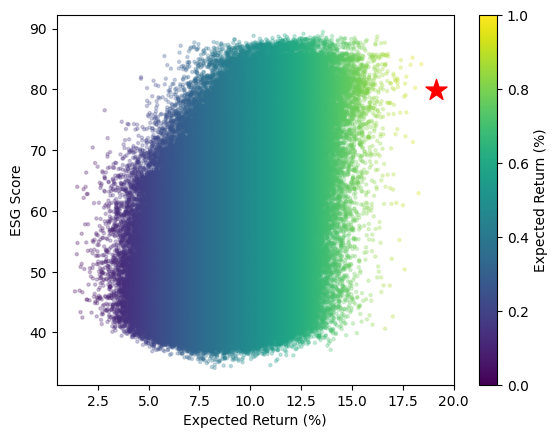

In [22]:
best = all_results_df.loc[all_results_df["return"].idxmax()]

plt.scatter(all_results_df["return"]*100, all_results_df["esg"],
            c=all_results_df["return"]*100, cmap="viridis", s=5, alpha=0.25)

plt.scatter(best["return"]*100, best["esg"], c="red", marker="*", s=250)

plt.xlabel("Expected Return (%)")
plt.ylabel("ESG Score")
plt.colorbar(label="Expected Return (%)")
plt.show()

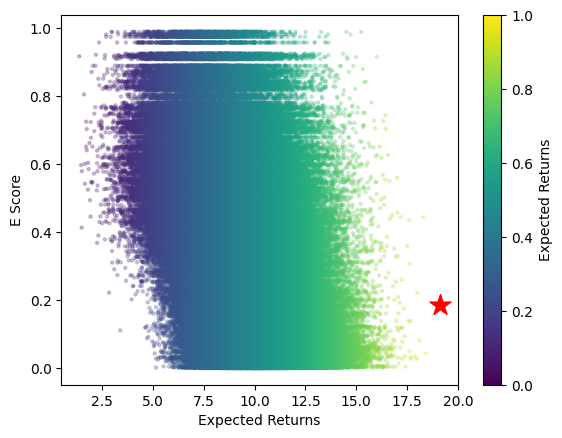

In [23]:
best = all_results_df.loc[all_results_df["return"].idxmax()]

plt.scatter(all_results_df["return"]*100, e_pillar,
            c=all_results_df["return"]*100, cmap="viridis", s=5, alpha=0.25)

plt.scatter(best["return"]*100, best['pillar_weights'][0], c="red", marker="*", s=250)

plt.xlabel("Expected Returns")
plt.ylabel("E Score")
plt.colorbar(label="Expected Returns")
plt.show()

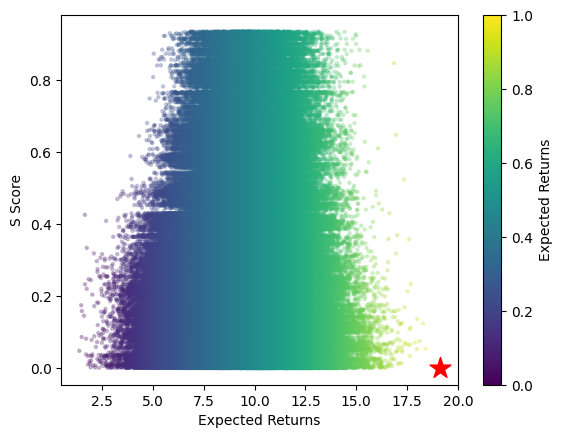

In [24]:
best = all_results_df.loc[all_results_df["return"].idxmax()]

plt.scatter(all_results_df["return"]*100, s_pillar,
            c=all_results_df["return"]*100, cmap="viridis", s=5, alpha=0.25)

plt.scatter(best["return"]*100, best['pillar_weights'][1], c="red", marker="*", s=250)

plt.xlabel("Expected Returns")
plt.ylabel("S Score")
plt.colorbar(label="Expected Returns")
plt.show()

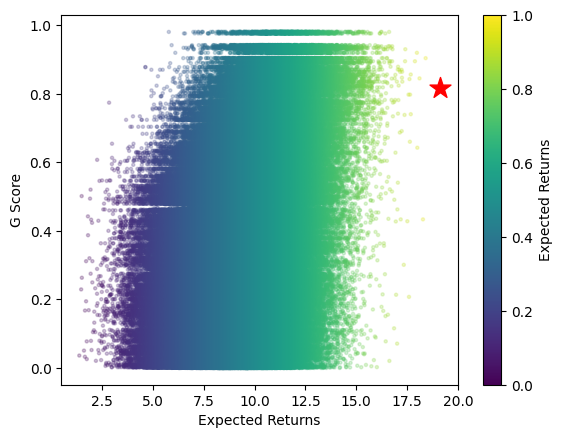

In [25]:
best = all_results_df.loc[all_results_df["return"].idxmax()]

plt.scatter(all_results_df["return"]*100, g_pillar,
            c=all_results_df["return"]*100, cmap="viridis", s=5, alpha=0.25)

plt.scatter(best["return"]*100, best['pillar_weights'][2], c="red", marker="*", s=250)

plt.xlabel("Expected Returns")
plt.ylabel("G Score")
plt.colorbar(label="Expected Returns")
plt.show()

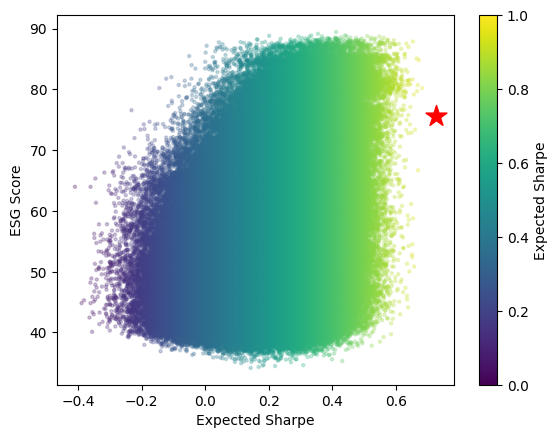

In [26]:
best = all_results_df.loc[all_results_df["sharpe"].idxmax()]

plt.scatter(all_results_df["sharpe"], all_results_df["esg"],
            c=all_results_df["sharpe"], cmap="viridis", s=5, alpha=0.25)

plt.scatter(best["sharpe"], best["esg"], c="red", marker="*", s=250)

plt.xlabel("Expected Sharpe")
plt.ylabel("ESG Score")
plt.colorbar(label="Expected Sharpe")
plt.show()